<a href="https://colab.research.google.com/github/poorvikapalan/machine_learning/blob/main/program6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score



In [5]:
# Larger dataset
data = {
    "Sky": ["Sunny","Sunny","Rainy","Sunny","Cloudy","Rainy","Sunny","Cloudy","Sunny","Rainy"],
    "Temperature": ["Warm","Warm","Cold","Warm","Warm","Cold","Cold","Warm","Warm","Cold"],
    "Humidity": ["Normal","High","High","Normal","High","Normal","Normal","High","Normal","High"],
    "Wind": ["Strong","Strong","Strong","Weak","Weak","Strong","Weak","Strong","Weak","Strong"],
    "Water": ["Warm","Warm","Warm","Cool","Warm","Cool","Warm","Warm","Cool","Warm"],
    "Forecast": ["Same","Same","Change","Change","Same","Change","Same","Same","Change","Change"],
    "Output": ["Yes","Yes","No","Yes","Yes","No","No","Yes","Yes","No"]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

dataset = df.values.tolist()



Dataset:

      Sky Temperature Humidity    Wind Water Forecast Output
0   Sunny        Warm   Normal  Strong  Warm     Same    Yes
1   Sunny        Warm     High  Strong  Warm     Same    Yes
2   Rainy        Cold     High  Strong  Warm   Change     No
3   Sunny        Warm   Normal    Weak  Cool   Change    Yes
4  Cloudy        Warm     High    Weak  Warm     Same    Yes
5   Rainy        Cold   Normal  Strong  Cool   Change     No
6   Sunny        Cold   Normal    Weak  Warm     Same     No
7  Cloudy        Warm     High  Strong  Warm     Same    Yes
8   Sunny        Warm   Normal    Weak  Cool   Change    Yes
9   Rainy        Cold     High  Strong  Warm   Change     No


In [6]:
specific = dataset[0][:-1]
general = [["?" for i in range(len(specific))] for j in range(len(specific))]

noise = 0

print("\nInitial Specific Hypothesis:", specific)
print("Initial General Hypothesis:", general)

# Training
for step, example in enumerate(dataset):

    if example[-1] == "Yes":

        for j in range(len(specific)):
            if example[j] != specific[j]:
                specific[j] = "?"
                general[j][j] = "?"

    elif example[-1] == "No":

        noise += 1

        for j in range(len(specific)):
            if example[j] != specific[j]:
                general[j][j] = specific[j]
            else:
                general[j][j] = "?"

    print("\nStep", step+1)
    print("Specific:", specific)
    print("General:", general)

# Remove empty hypotheses
gh = []
for i in general:
    if i.count("?") != len(i):
        gh.append(i)

print("\nFinal Specific Hypothesis:", specific)
print("Final General Hypothesis:", gh)
print("Noise Examples Detected:", noise)


Initial Specific Hypothesis: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
Initial General Hypothesis: [['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]

Step 1
Specific: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
General: [['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]

Step 2
Specific: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
General: [['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]

Step 3
Specific: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
General: [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?'], ['?'

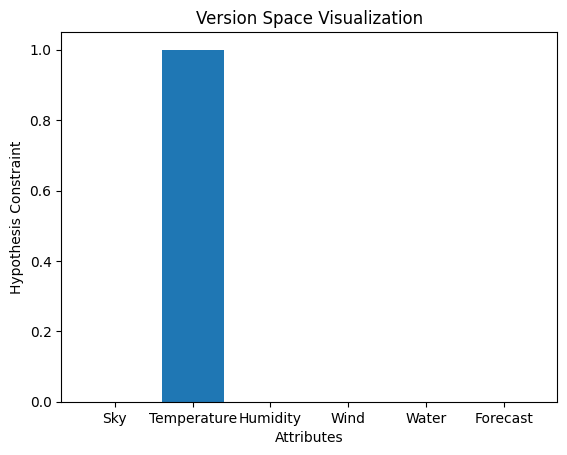

In [7]:
attributes = df.columns[:-1]

constraints = []

for val in specific:
    if val == "?":
        constraints.append(0)
    else:
        constraints.append(1)

plt.bar(attributes, constraints)

plt.xlabel("Attributes")
plt.ylabel("Hypothesis Constraint")
plt.title("Version Space Visualization")
plt.show()


In [8]:
le = LabelEncoder()

X = df.iloc[:,:-1].apply(le.fit_transform)
y = le.fit_transform(df["Output"])

model = DecisionTreeClassifier()
model.fit(X,y)

pred = model.predict(X)

acc = accuracy_score(y,pred)

print("\nDecision Tree Accuracy:", acc)


Decision Tree Accuracy: 1.0
